In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [5]:
from src.data.grid import MagnetGridIterator
iterator = MagnetGridIterator(
    "../data/processed/batch_6/grid_voxel_size_4_data_type_float32",
    phase_samples_per_simulation=2,
)

In [8]:
import torch
from torch.utils.data import DataLoader
import numpy as np

dl = DataLoader(iterator, batch_size=1, num_workers=2)
item = next(iter(dl))

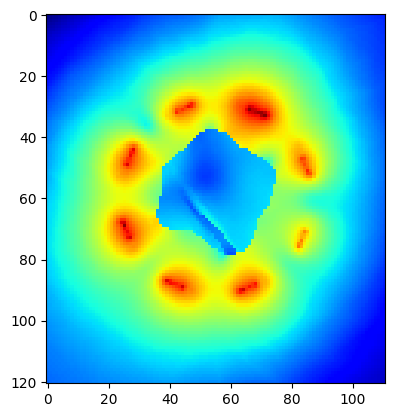

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Ground truth

re = item['field'][0, 0, 0, :, :, :, :]
im = item['field'][0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].cpu().numpy(), cmap='jet', norm='log')
plt.show()

In [ ]:
from src.models import LitUNet3D

trained_model = LitUNet3D.load_from_checkpoint(
    '/Users/mariusbohn/Documents/Studium/MA/ma_bohn/examples/lightning_logs/version_2182194/checkpoints/epoch=19-step=2100.ckpt'
    )

inputs = item['input']
coils = item['coils']
x = torch.cat((inputs, coils), dim=1)

pred = trained_model.eval().model(x).view((1, 2, 2, 3, 121, 111, 126))

In [ ]:
re = pred[0, 0, 0, :, :, :, :]
im = pred[0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].detach().numpy(), cmap='jet', norm='log')
plt.show()

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/